# Tutorial 1: **Working With Images Using OpenCV**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## What is OpenCV and why is it used?

OpenCV (Open Source Computer Vision Library) is an open-source computer vision and machine learning software library. It contains more than 2500 optimized algorithms for various computer vision tasks. It is widely used for image processing, video capture, and analysis, including facial recognition, object detection, and tracking.


## Importing Libraries

In [ ]:
# Import necessary libraries
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

## Loading an Image

In [ ]:
img=cv2.imread("/content/drive/MyDrive/imageA.jpeg")

## Displaying Image using cv2

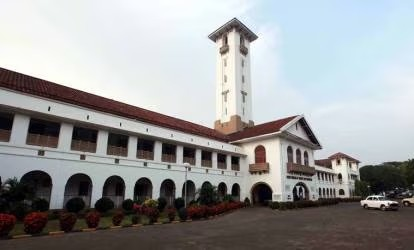

In [ ]:
cv2_imshow(img)

## Reading and Displaying image as GRAY SCALE

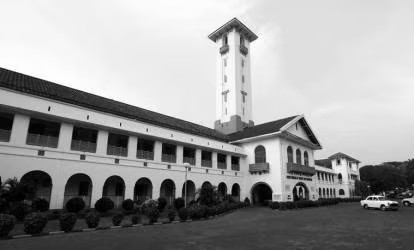

if you were in 70s !!


In [ ]:
gray_image=cv2.imread("/content/drive/MyDrive/imageA.jpeg",cv2.IMREAD_GRAYSCALE)
cv2_imshow(gray_image)
print("if you were in 70s !!")

array([[245, 245, 245, ..., 223, 223, 223],
       [245, 245, 245, ..., 223, 223, 223],
       [245, 245, 245, ..., 223, 223, 223],
       ...,
       [ 48,  48,  48, ...,  55,  55,  55],
       [ 45,  45,  45, ...,  55,  55,  55],
       [ 46,  46,  46, ...,  55,  55,  55]], dtype=uint8)
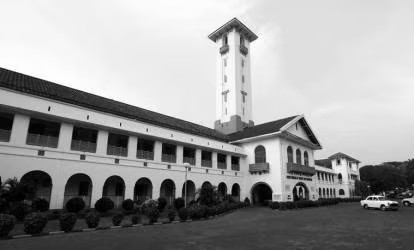

In [ ]:
gray_image

## Negative of an Image

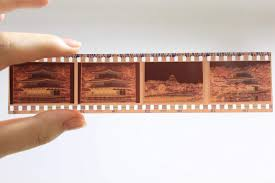

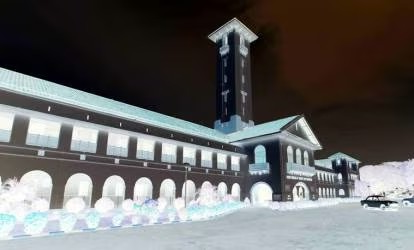

In [ ]:
# Negative of a color image
negative_color = 255 - img
cv2_imshow(negative_color)


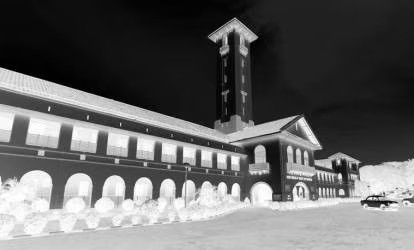

In [ ]:
### Generating the negative of an image (in grayscale and color)
# Negative of a grayscale image
negative_gray = 255 - gray_image
cv2_imshow(negative_gray)

## Splitting image Accross channes

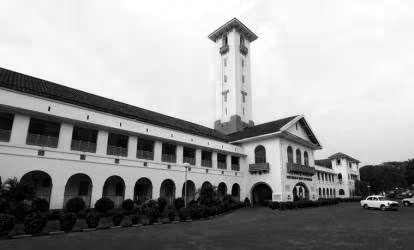

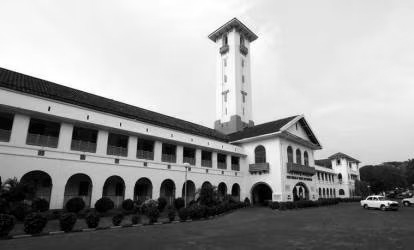

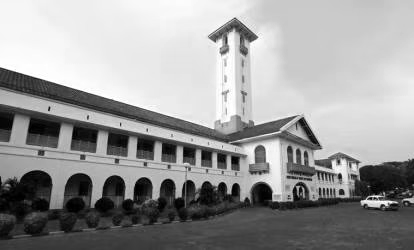

In [ ]:
#first way
#b, g, r = img[..., 0], img[..., 1], img[..., 2]

#second way
#b, g, r = img[:, :, 0], img[:, :, 1], img[:, :, 2]

#third way (using cv2)

b, g, r = cv2.split(img)
# Display color channels
cv2_imshow(b)
cv2_imshow(g)
cv2_imshow(r)

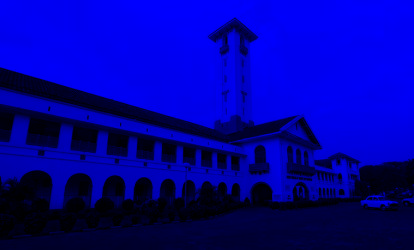

In [ ]:
temp=img.copy()
temp[:,:,1]=0
temp[:,:,2]=0
cv2_imshow(temp)

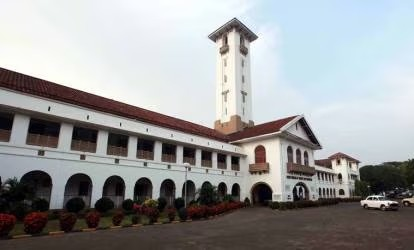

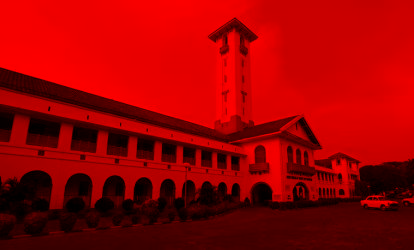

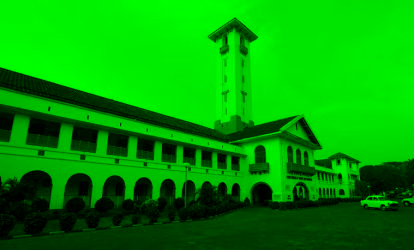

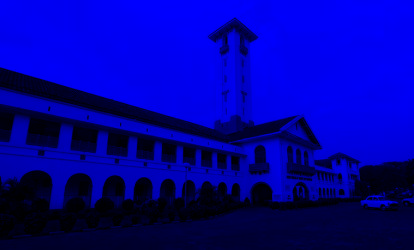

In [ ]:
# Create blank channel for visualization
zeros = np.zeros_like(b)

# Merge each channel with zeros to visualize in color
red_img = cv2.merge([zeros, zeros, r])
green_img = cv2.merge([zeros, g, zeros])
blue_img = cv2.merge([b, zeros, zeros])

#displaying images
cv2_imshow(img)
print("Orignal Image")
cv2_imshow(red_img)
print("Straight out of a Horror Movie, THE RED MUSEUM!!")
cv2_imshow(green_img)
print("lil scary!!!")
cv2_imshow(blue_img)
print("Don't visit there in the Dark..It's Haunted!!")

**Just Kidding..**

**Timing:**
Monday to Friday: 9:30 AM to 5 PM

Saturday and Sunday: Closed

## Using Matplot Library

## Colorspaces and order of color channels: RGB vs BGR

In OpenCV, the default color space is BGR (Blue-Green-Red), which is different from the RGB (Red-Green-Blue) order commonly used in other libraries like matplotlib.

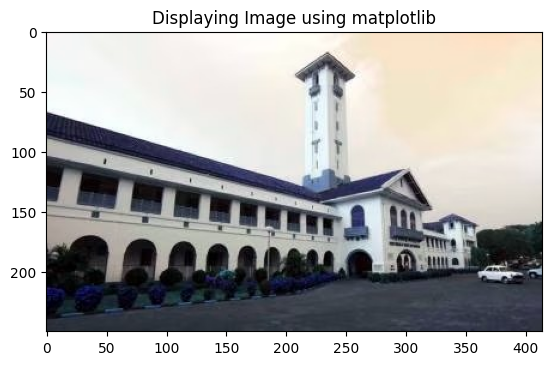

In [ ]:
import matplotlib.pyplot as plt
plt.title("Displaying Image using matplotlib")
plt.imshow(img)

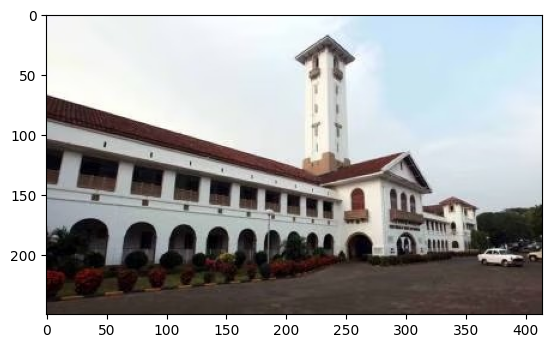

In [ ]:
#convert BGR to RGB
image_new = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_new)

## Just few Helper Functions

In [ ]:
# Utility function to display images
def display_image(image, cmap_type='gray'):
    image_new = cv2.resize(image, None, fx=1, fy=1, interpolation=cv2.INTER_NEAREST)
    cv2_imshow(image_new)

def display_image_plt(image, cmap_type='gray'):
    if len(image.shape) == 3: # Color image
        cmap_type = None
    image_new = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_new, cmap=cmap_type)
    plt.show()

## RGB to YUV

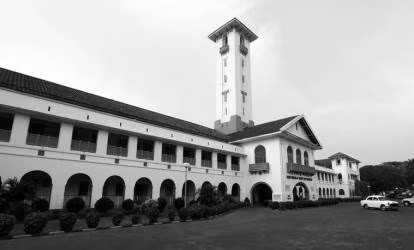

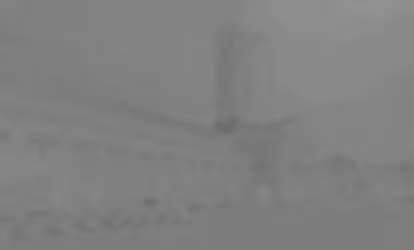

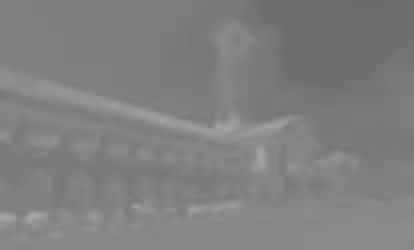

In [ ]:
yuv_image = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
y_channel, u_channel, v_channel = cv2.split(yuv_image)

display_image(y_channel)
display_image(u_channel)
display_image(v_channel)

## RGB to HSV

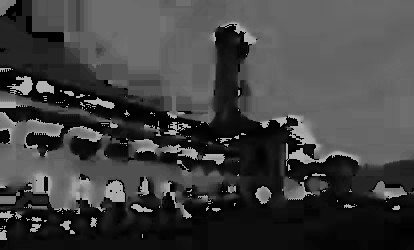

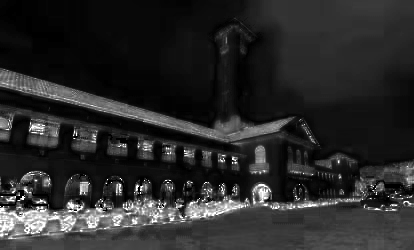

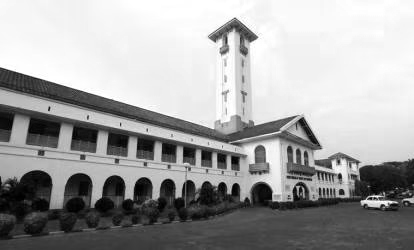

In [ ]:
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h_channel, s_channel, v_channel_hsv = cv2.split(hsv_image)
display_image(h_channel)
display_image(s_channel)
display_image(v_channel_hsv)

## Adjusting the brightness and contrast of images (power law transformations)

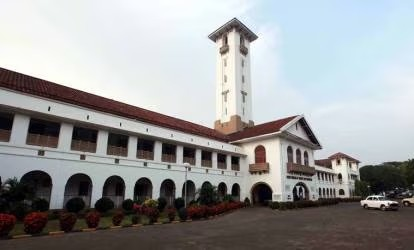

In [ ]:
gamma = 1
adjusted = np.array(255*(img / 255) ** gamma, dtype = 'uint8')

display_image(adjusted, cv2.COLOR_BGR2RGB)

## Bit plane slicing – extracting and displaying individual bit planes of images

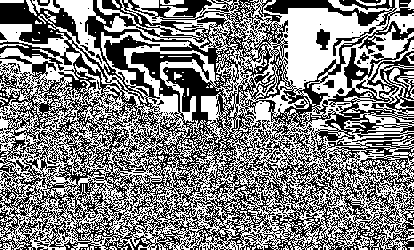

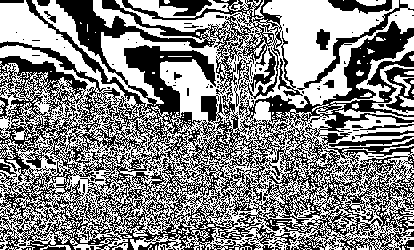

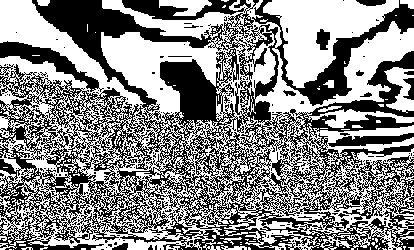

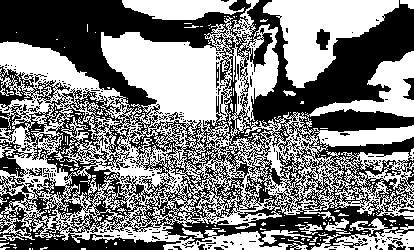

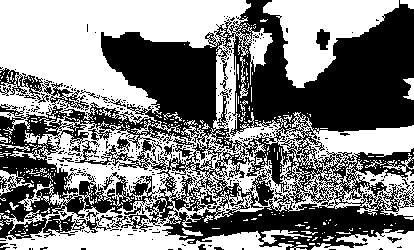

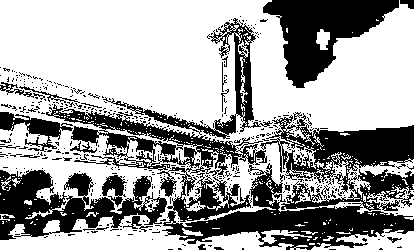

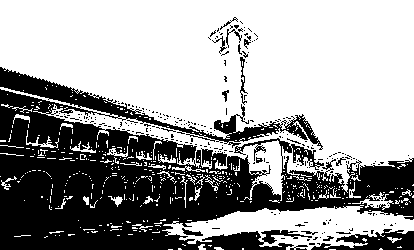

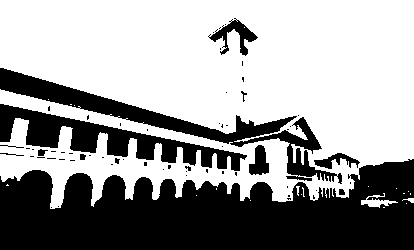

In [ ]:
def bit_plane_slicing(image, bit_plane):
    rows, cols = image.shape
    bit_plane_image = np.zeros((rows, cols), dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            bit_plane_image[i, j] = (image[i, j] & (1 << bit_plane)) >> bit_plane
    return bit_plane_image

bit_planes = [bit_plane_slicing(gray_image, i) for i in range(8)]
for i, bp in enumerate(bit_planes):
    display_image(bp * 255.0)

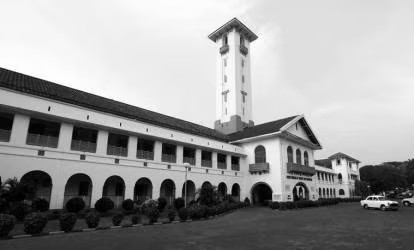

In [ ]:
reconstructed_image = [bit_planes[i] << i for i in range(8)]
reconstructed_image = np.sum(np.array(reconstructed_image, dtype=np.uint8), axis=0, dtype=np.uint8)
display_image(reconstructed_image)

## Pixelwise operation on images – addition, subtraction, multiplication, division

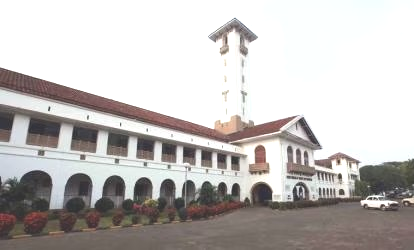

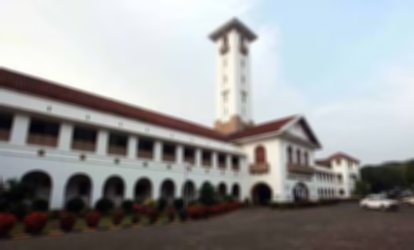

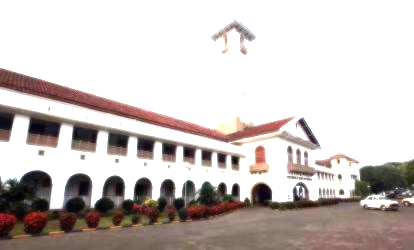

In [ ]:
# Example: Addition of scalar value
brightened_image = cv2.add(img, np.array([50.0, 50.0, 50.0]))
display_image(brightened_image)

# Example: Addition of two images
blurred_image = cv2.blur(img, (5, 5))
display_image(blurred_image)

bloom_image = cv2.add(img, blurred_image)
display_image(bloom_image)

## Resizing Images

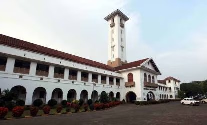

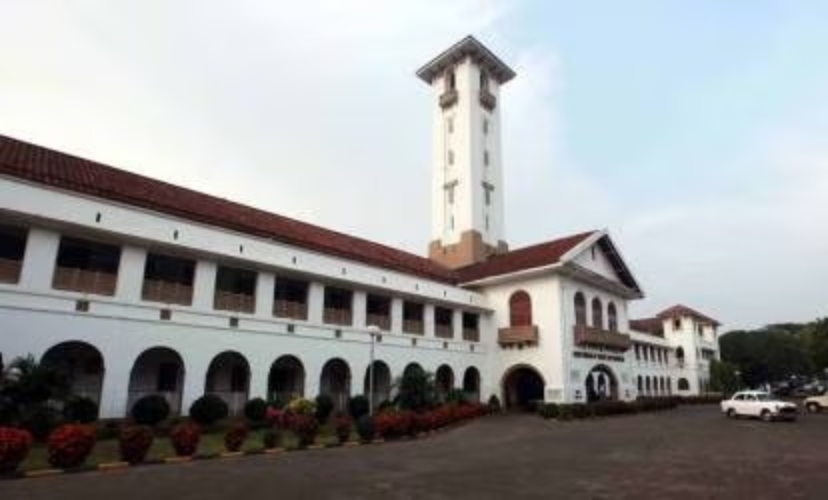

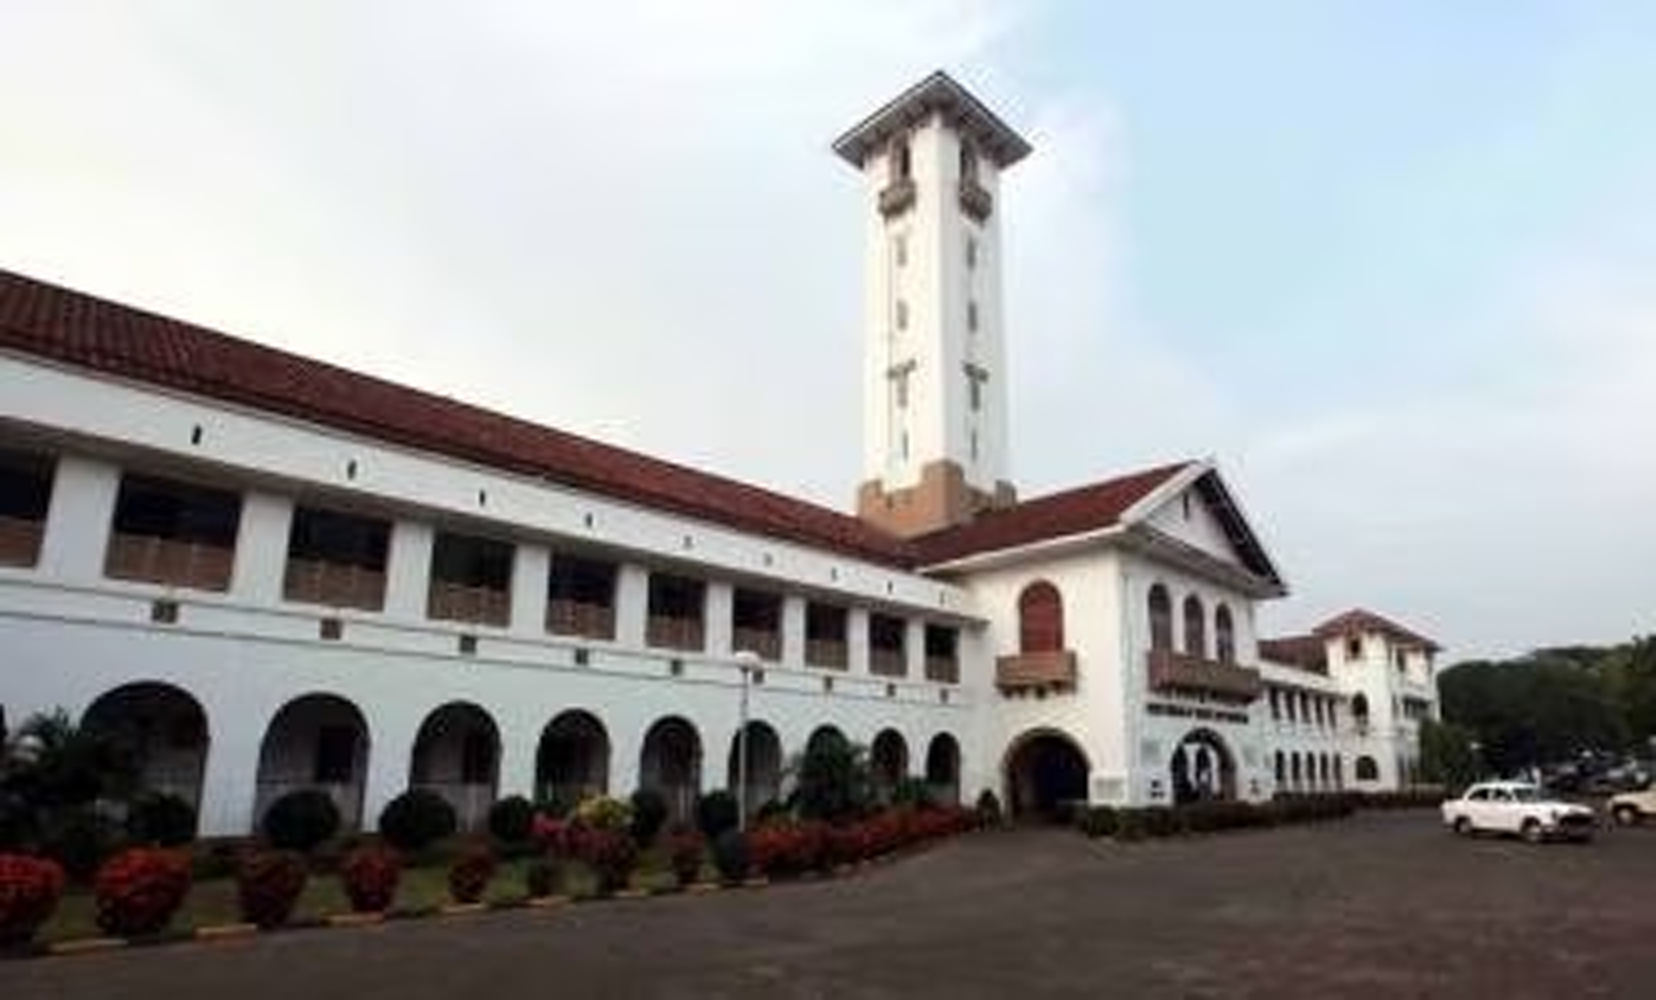

In [ ]:
### Resizing images – downsampling and upsampling images
# Nearest neighbor interpolation
resized_image_nn = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)
display_image(resized_image_nn)

# Bilinear interpolation
resized_image_bl = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
display_image(resized_image_bl)

# Bicubic interpolation
resized_image_bc = cv2.resize(img, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)
display_image(resized_image_bc)

## Cropping Images

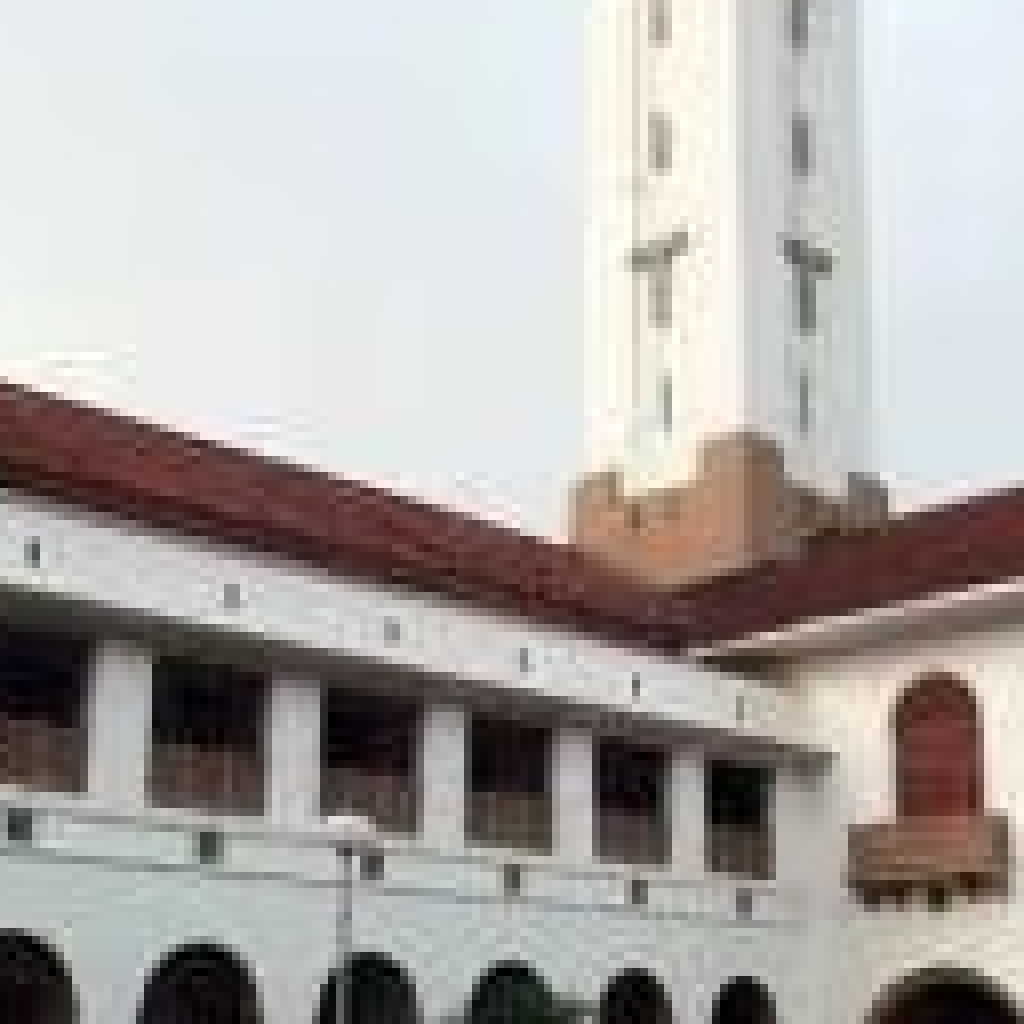

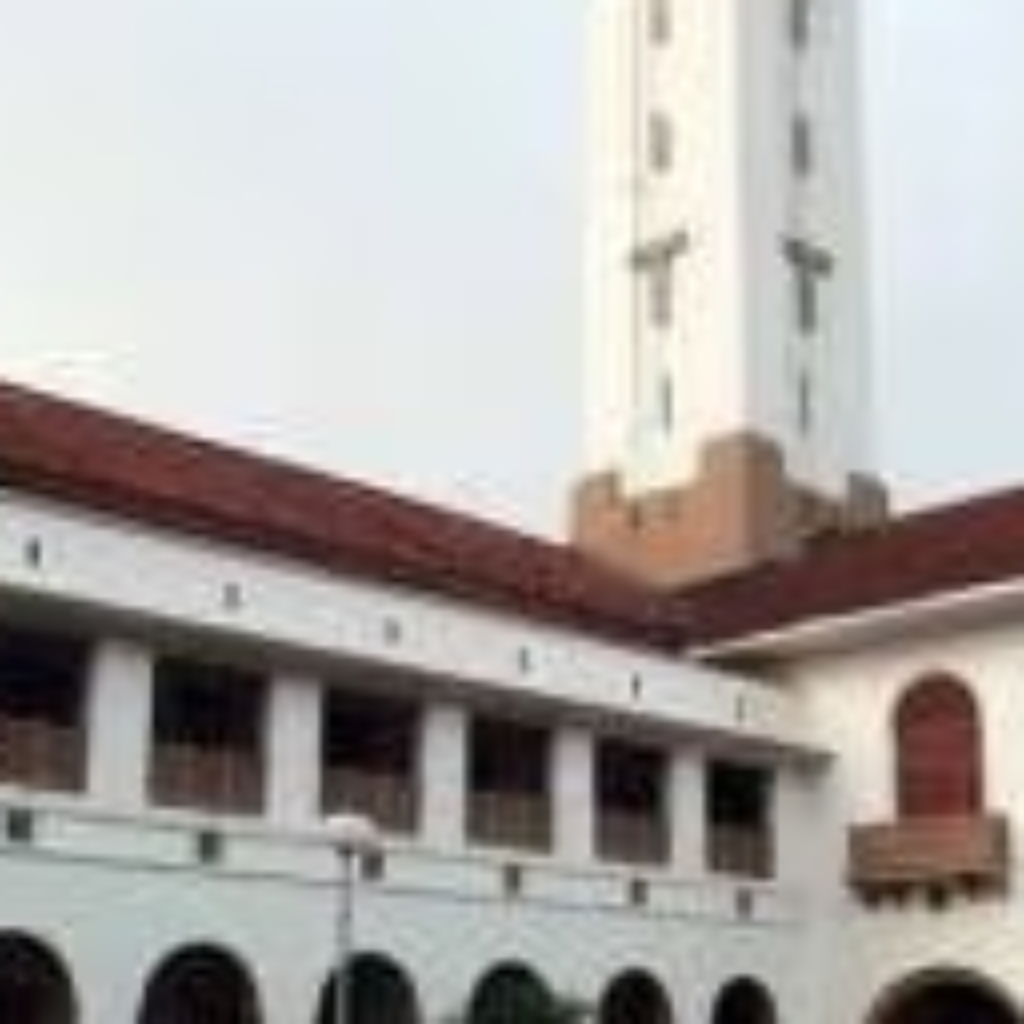

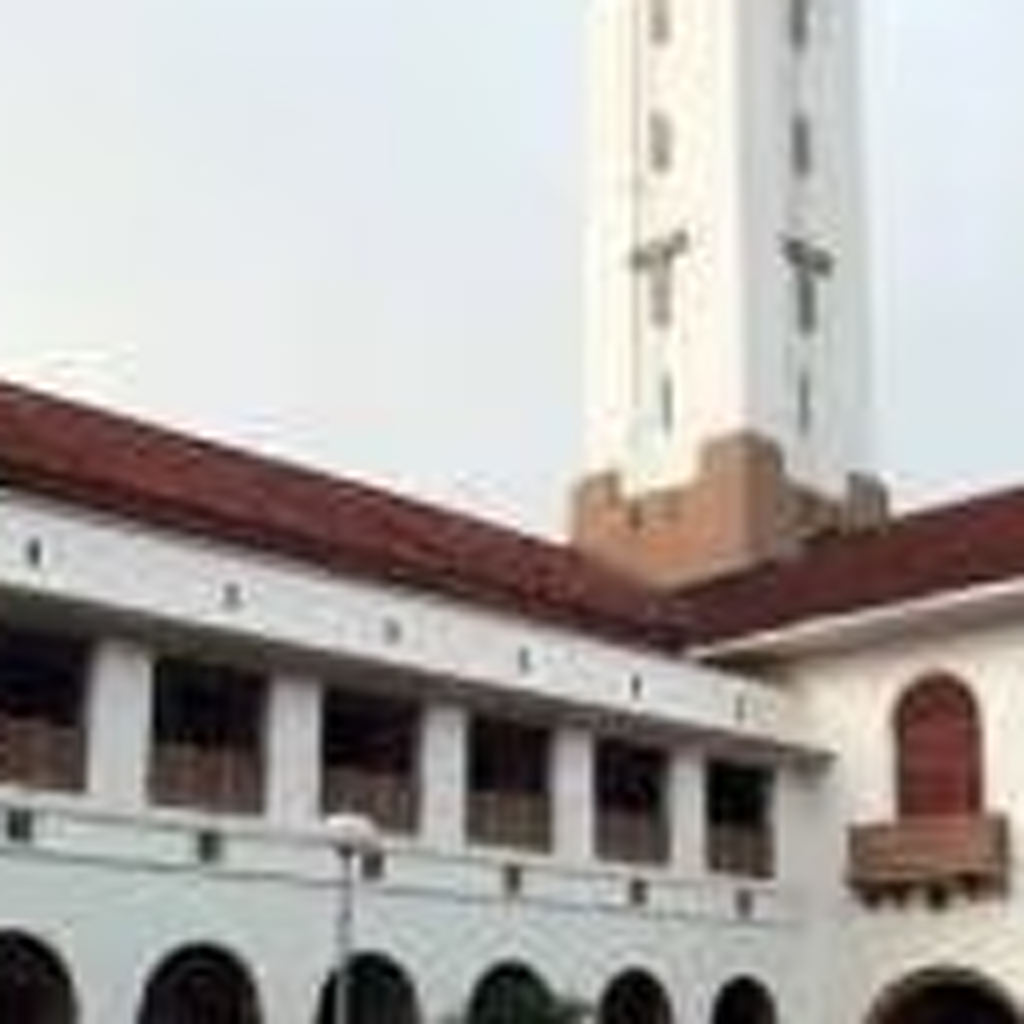

In [ ]:
w = 128
h = 128
center = img.shape
x = int((center[1] / 2) - (w/2))
y = int((center[0] / 2) - (h/2))

cropped_image = img[y:y+h, x:x+w]

# Nearest neighbor interpolation
resized_image_nn = cv2.resize(cropped_image, None, fx=8, fy=8, interpolation=cv2.INTER_NEAREST)
display_image(resized_image_nn)

# Bilinear interpolation
resized_image_bl = cv2.resize(cropped_image, None, fx=8, fy=8, interpolation=cv2.INTER_LINEAR)
display_image(resized_image_bl)

# Bicubic interpolation
resized_image_bc = cv2.resize(cropped_image, None, fx=8, fy=8, interpolation=cv2.INTER_CUBIC)
display_image(resized_image_bc)

## Flipping and rotating images

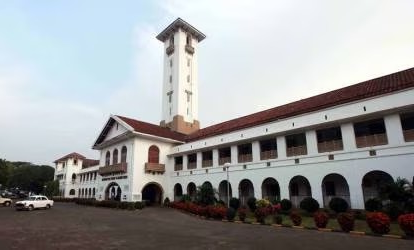

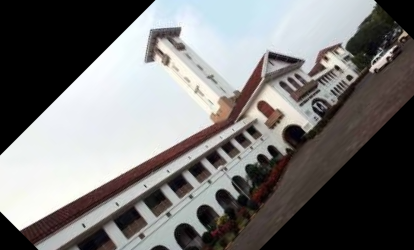

In [ ]:
# Flipping
flipped_image = cv2.flip(img, 1)
display_image(flipped_image)

# Rotating
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
matrix = cv2.getRotationMatrix2D(center, 45, 1)
rotated_image = cv2.warpAffine(img, matrix, (w, h))
display_image(rotated_image)

## Colormaps and their use

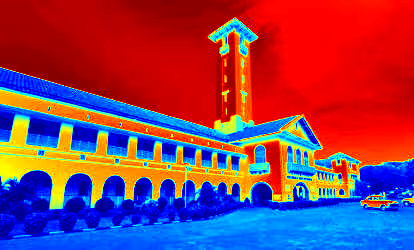

In [ ]:
colormap_image = cv2.applyColorMap(gray_image, cv2.COLORMAP_JET)
display_image(colormap_image)

## Annotating an image – drawing shapes and overlaying text

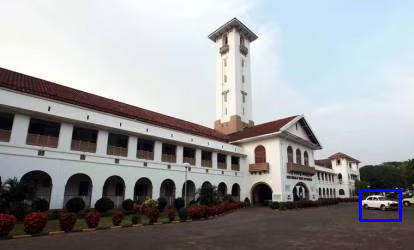

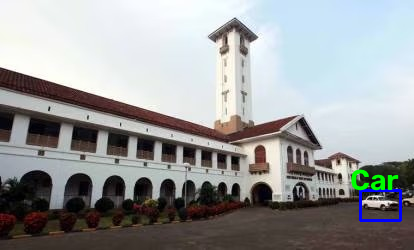

In [ ]:
# Drawing a rectangle
annotated_image = img.copy()
cv2.rectangle(annotated_image, (360, 190), (400, 220), (255, 0, 0), 2)
display_image(annotated_image)

# Overlaying text
#cv2.putText(image, text, org, fontFace, fontScale, color, thickness, lineType, bottomLeftOrigin)
cv2.putText(annotated_image, 'Car', (350, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
display_image(annotated_image)


# If You Need Any Help
Reach Out To Me
lovishkaushik.24@kgpian.iitkgp.ac.in



## Other image processing libraries

### Scikit-image

Scikit-image is a collection of algorithms for image processing. It is part of the SciPy ecosystem and is designed to interoperate with NumPy and other libraries in the SciPy stack. It is known for its easy-to-use interface and wide range of algorithms.


### Pillow

Pillow is a fork of the Python Imaging Library (PIL). It adds support for opening, manipulating, and saving many different image file formats. It is known for its simplicity and ease of use.


### When to use each library

- OpenCV: Best for real-time computer vision applications, extensive functionality for image and video processing, optimized for performance.
- Scikit-image: Ideal for scientific image analysis, offers a wide range of algorithms and easy integration with other SciPy stack libraries.
- Pillow: Great for basic image manipulation, supports many image file formats, simple and easy to use.


[Assignment 1](https://colab.research.google.com/drive/1l3AdLmpf_seTT7AYzUQnkyMRHIH2OBMc?usp=sharing)